In [7]:
import itertools 
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment

from visualization import (
    bulk_vs_singlecell_matrix_viz,
    loop_heatmap_plots_real_data,
    super_plot_heatmaps_real_data,
    barplot_matches_nonmatches_na,
    super_plot_heatmaps_real_data_multimodal_hgsoc,
    plot_combined_heatmaps_datasets,
    row_heatmap_plot_real_data
 )
from accuracy_functions import load_expected_matches_real_data, find_mismatches_real_data
from analysis_shared_functions import (
    parse_heatmap_matrix_hysys,
    parse_heatmap_matrix_crosscheckfingerprints,
    load_heatmap_data,
)

In [2]:
DATA_PATH = "../benchmarking/data/output_data/vcf_update" # Path to the directory containing the data files
FIGURES_PATH = "../benchmarking/data/figures/" # Path to the directory where the figures will be saved

In [3]:
# Generally all the combinations of these parameters are present in the data, 
# except for BAMixChecker which only has results for read depth 0.
# And occassionally, tools may be missing results because they failed to run for certain combinations of parameters.
tools = [
    "Conpair", 
    "CrosscheckFingerprints", 
    "HYSYS", 
    "NGSCheckmate", 
    "ntsm",
    "OmicsPrint", 
    "Peddy", 
    "Somalier", 
    "TimeAttackGenComp",
    "Vireo"
]
read_depths_mod1 = [0, 10, 40]
read_depths_mod2 = [0, 10, 40]
datasets = ["hgsoc", "hgsoc-new", "high_grade_glioma", "low_grade_glioma", "wilms_tumor"]

# Sample similarity heatmaps

Processing tool Conpair, dataset high_grade_glioma, read depth bulk_0_single-cell_0...
Processing tool Conpair, dataset high_grade_glioma, read depth bulk_10_single-cell_10...
Processing tool Conpair, dataset high_grade_glioma, read depth bulk_40_single-cell_40...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth bulk_0_single-cell_0...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth bulk_10_single-cell_10...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth bulk_40_single-cell_40...
Processing tool HYSYS, dataset high_grade_glioma, read depth bulk_0_single-cell_0...
Processing tool HYSYS, dataset high_grade_glioma, read depth bulk_10_single-cell_10...
Processing tool HYSYS, dataset high_grade_glioma, read depth bulk_40_single-cell_40...
Processing tool NGSCheckmate, dataset high_grade_glioma, read depth bulk_0_single-cell_0...
Processing tool NGSCheckmate, dataset high_grade_glioma, read depth bulk_1

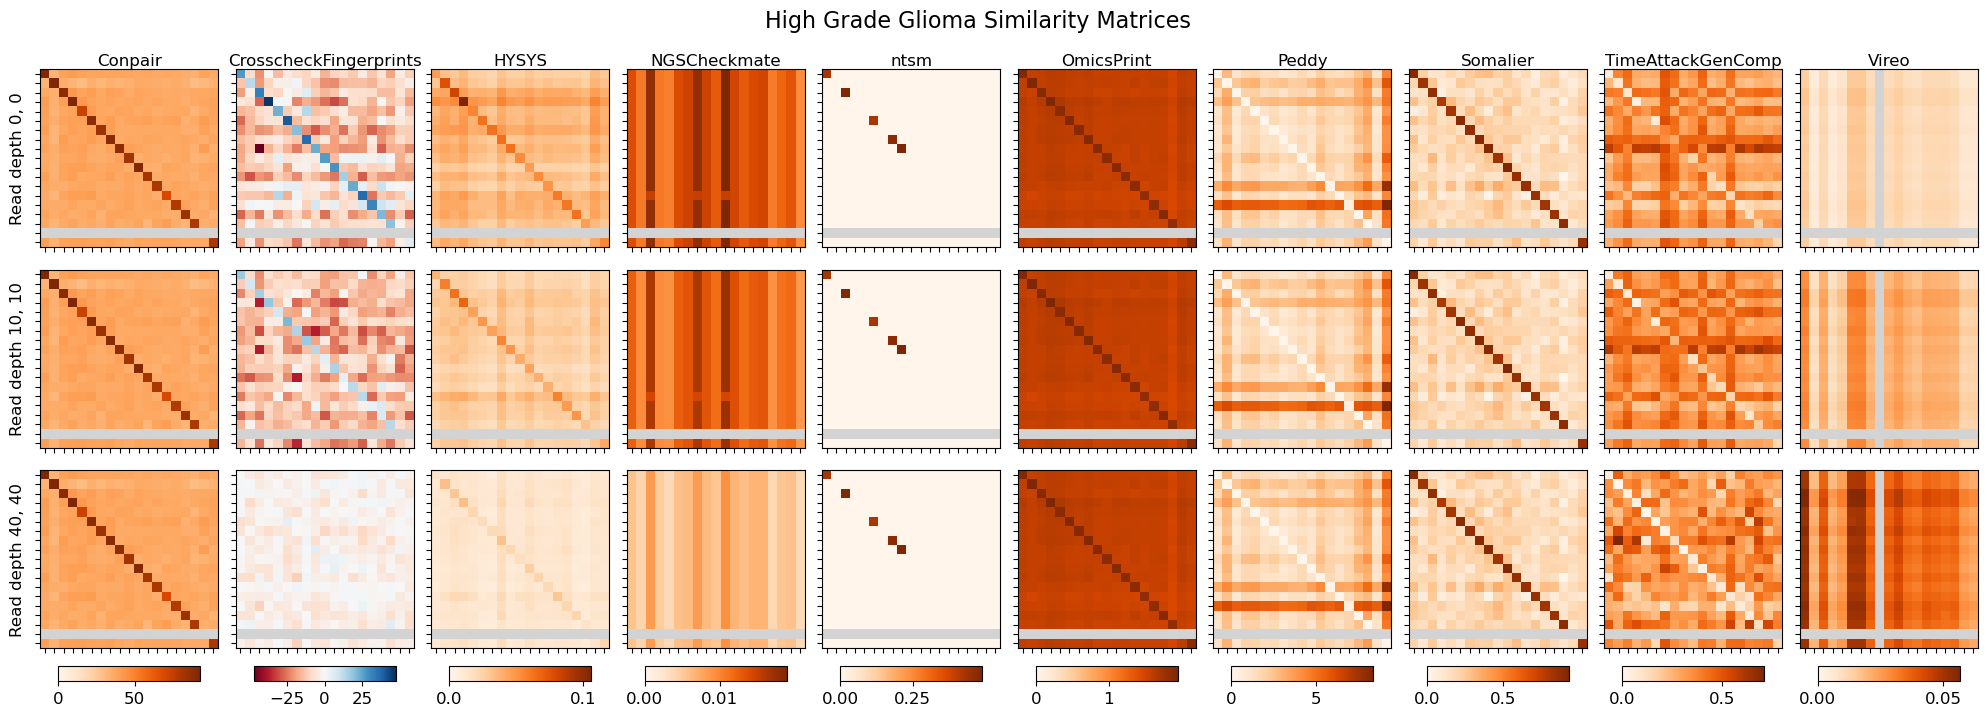

In [ ]:
# Plot A of real data plot
super_plot_heatmaps_real_data(
    DATA_PATH=DATA_PATH,
    FIGURES_PATH=FIGURES_PATH,
    tools=tools,
    dataset="high_grade_glioma",
    read_depths_mod1=[0, 10, 40],
    read_depths_mod2=[0, 10, 40],
    mod1="bulk",
    mod2="single-cell",
    remove_missing_data=False,
    save_fig=True,
)

Processing tool Conpair, dataset wilms_tumor, read depth bulk_0_single-nucleus_0...
Processing tool Conpair, dataset hgsoc, read depth single-cell_0_bulk_dissociated_ribo_0...
Processing tool Conpair, dataset low_grade_glioma, read depth bulk_0_single-cell_0...


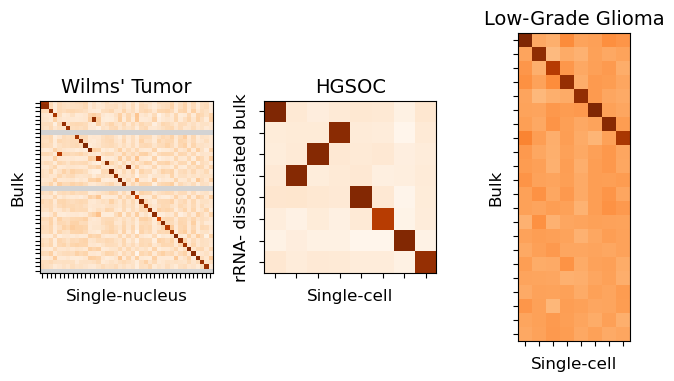

In [4]:
# Plot B of real data plot
plot_combined_heatmaps_datasets(
    DATA_PATH=DATA_PATH,
    FIGURES_PATH=FIGURES_PATH,
    save_fig=True,
)

In [9]:
load_heatmap_data(DATA_PATH, False, "Conpair", "hgsoc-new", "null", "bulk_diss_polyA_0_bulk_chunk_ribo_0", "bulk_chunk_ribo", "bulk_diss_polyA")

Processing tool Conpair, dataset hgsoc-new, read depth bulk_diss_polyA_0_bulk_chunk_ribo_0...


,HGSOC-2268_ds.083794fba95c4554b7d41ccc652ac943_bulk_chunk_ribo,HGSOC-2466_ds.08b3c08e64a44ef4a48c35baa4796d1b_bulk_diss_polyA,HGSOC-2477_ds.0af6a47fc92a4675b1f6c60ae2a863d9_bulk_diss_polyA,HGSOC-2455_ds.17f92227aa344ad7851c0da5c10baddf_bulk_diss_polyA,HGSOC-2186_ds.18debb70861d4f0b8cbe8f15664d40e6_bulk_diss_polyA,HGSOC-2416_ds.1dcfade89cc644baad1faaac5c89573a_bulk_diss_polyA,HGSOC-2238_ds.1e19d229b15747be9f77e064ebe8a467_bulk_chunk_ribo,HGSOC-2483_ds.2007dc0d3e9048f0b64e4792f533e622_bulk_diss_polyA,HGSOC-2309_ds.20b83c26912b4789adf0ba742df749c7_bulk_chunk_ribo,HGSOC-2526_ds.22414930847544d28aeb703fe56f43cf_bulk_diss_polyA,...,HGSOC-2526_ds.d8d90e02e98d4986bb06fb5256a51e13_bulk_chunk_ribo,HGSOC-2401_ds.d913e45f78bf4299a16d2b713937961d_bulk_diss_polyA,HGSOC-2230_ds.dc1081facbaa4199b207fd619422c83b_bulk_diss_polyA,HGSOC-2278_ds.e70b101c0d594d709e7ebf0367726bb4_bulk_chunk_ribo,HGSOC-2238_ds.e7767fb943124326a98f3affeb9d722c_bulk_diss_polyA,HGSOC-2460_ds.e975eb3f47824d4ab8c8b30e6feca083_bulk_chunk_ribo,HGSOC-2129_ds.eebdcd4b684b488ba880d33dab05a78c_bulk_chunk_ribo,HGSOC-2408_ds.ef75a27f504940d2b2390241b0e3abe3_bulk_diss_polyA,HGSOC-2401_ds.f9c04c189deb4200933e4e873974f5c3_bulk_chunk_ribo,HGSOC-2444_ds.fdd3a47b8c5a445f9918dd57215051f3_bulk_chunk_ribo
sample1,,,,,,,,,,,,,,,,,,,,,
HGSOC-2268_ds.083794fba95c4554b7d41ccc652ac943_bulk_chunk_ribo,NaN,33.63,34.87,33.67,33.51,31.79,NaN,35.60,NaN,34.78,...,NaN,36.12,39.89,NaN,33.86,NaN,NaN,33.68,NaN,NaN
HGSOC-2466_ds.08b3c08e64a44ef4a48c35baa4796d1b_bulk_diss_polyA,33.63,NaN,NaN,NaN,NaN,NaN,38.62,NaN,38.08,NaN,...,32.15,NaN,NaN,36.64,NaN,93.52,40.30,NaN,36.33,39.93
HGSOC-2477_ds.0af6a47fc92a4675b1f6c60ae2a863d9_bulk_diss_polyA,34.87,NaN,NaN,NaN,NaN,NaN,38.16,NaN,37.69,NaN,...,33.38,NaN,NaN,38.92,NaN,40.23,37.02,NaN,39.20,39.90
HGSOC-2455_ds.17f92227aa344ad7851c0da5c10baddf_bulk_diss_polyA,33.67,NaN,NaN,NaN,NaN,NaN,38.71,NaN,39.08,NaN,...,33.26,NaN,NaN,39.38,NaN,38.51,39.11,NaN,38.54,92.19
HGSOC-2186_ds.18debb70861d4f0b8cbe8f15664d40e6_bulk_diss_polyA,33.51,NaN,NaN,NaN,NaN,NaN,40.07,NaN,39.98,NaN,...,34.02,NaN,NaN,38.61,NaN,39.17,39.36,NaN,39.35,39.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HGSOC-2460_ds.e975eb3f47824d4ab8c8b30e6feca083_bulk_chunk_ribo,NaN,93.52,40.23,38.51,39.17,34.01,NaN,38.09,NaN,39.95,...,NaN,39.99,34.08,NaN,39.36,NaN,NaN,39.62,NaN,NaN
HGSOC-2129_ds.eebdcd4b684b488ba880d33dab05a78c_bulk_chunk_ribo,NaN,40.30,37.02,39.11,39.36,32.60,NaN,39.33,NaN,39.05,...,NaN,40.86,33.99,NaN,41.64,NaN,NaN,38.45,NaN,NaN
HGSOC-2408_ds.ef75a27f504940d2b2390241b0e3abe3_bulk_diss_polyA,33.68,NaN,NaN,NaN,NaN,NaN,36.15,NaN,41.27,NaN,...,34.05,NaN,NaN,40.20,NaN,39.62,38.45,NaN,39.69,40.89


In [ ]:
# Plot A of dataset reconstruction figure
bulk_vs_singlecell_matrix_viz(
    DATA_PATH=DATA_PATH,
    pseudobulk=False,
    tool="Conpair",
    dataset="hgsoc-new",
    ncells="null",
    rd_mod1=0,
    rd_mod2=0,
    mod2="bulk_chunk_ribo",
    mod1="bulk_diss_polyA",
    save_fig=True,
    FIGURES_PATH=FIGURES_PATH   ,
)

Processing tool Conpair, dataset hgsoc-new, read depth bulk_chunk_ribo_0_bulk_diss_polyA_0...


Processing tool Conpair, dataset wilms_tumor, read depth bulk_0_single-nucleus_0...
Processing tool CrosscheckFingerprints, dataset wilms_tumor, read depth bulk_0_single-nucleus_0...
Processing tool HYSYS, dataset wilms_tumor, read depth bulk_0_single-nucleus_0...
Processing tool NGSCheckmate, dataset wilms_tumor, read depth bulk_0_single-nucleus_0...
Processing tool ntsm, dataset wilms_tumor, read depth bulk_0_single-nucleus_0...
Processing tool OmicsPrint, dataset wilms_tumor, read depth bulk_0_single-nucleus_0...
Processing tool Peddy, dataset wilms_tumor, read depth bulk_0_single-nucleus_0...
Processing tool Somalier, dataset wilms_tumor, read depth bulk_0_single-nucleus_0...
Processing tool TimeAttackGenComp, dataset wilms_tumor, read depth bulk_0_single-nucleus_0...
Processing tool Vireo, dataset wilms_tumor, read depth bulk_0_single-nucleus_0...


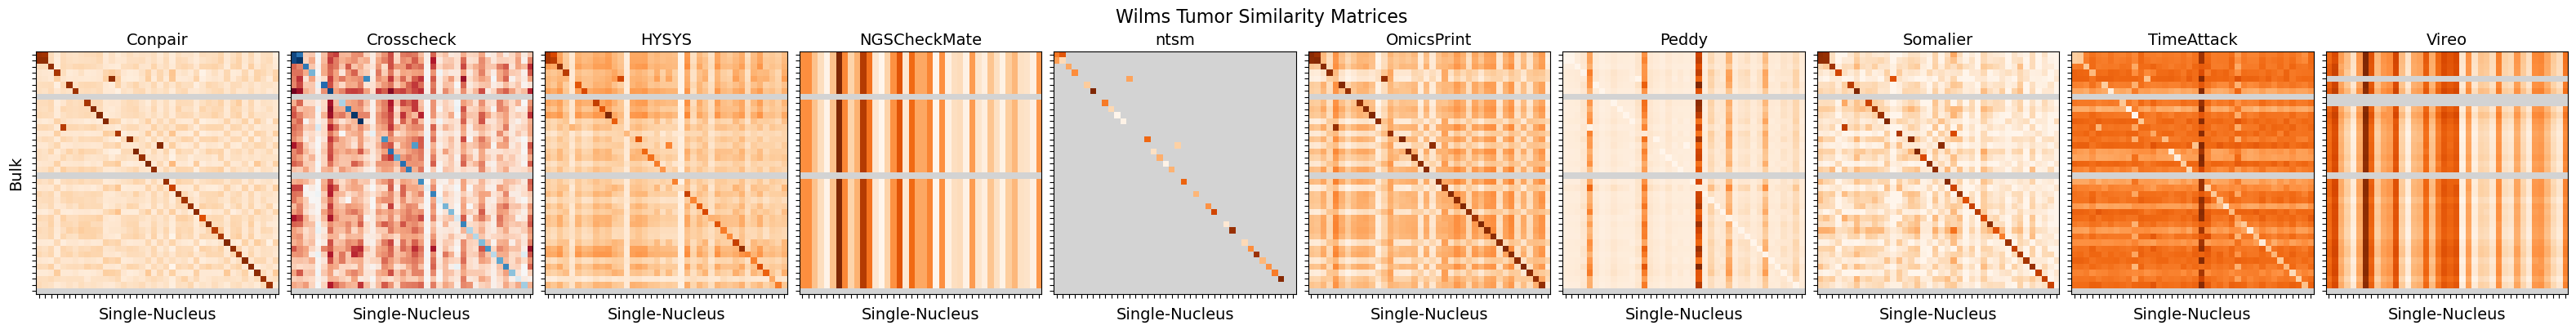

In [ ]:
# Figures for supplementary info
row_heatmap_plot_real_data(
    DATA_PATH=DATA_PATH,
    FIGURES_PATH=FIGURES_PATH,
    tools=tools,
    dataset="hgsoc",
    rd_mod1=0,
    rd_mod2=0,
    mod1="bulk",
    mod2="single-nucleus",
    hide_missing_samples=False,
    save_fig=True
)

Processing tool Conpair, dataset hgsoc, read depth 0...
Processing modalities single-cell vs bulk_dissociated_polyA for plotting...
Processing tool Conpair, dataset hgsoc, read depth 0...
Processing modalities single-cell vs bulk_dissociated_ribo for plotting...
Processing tool Conpair, dataset hgsoc, read depth 0...
Processing modalities single-cell vs bulk_chunk_ribo for plotting...
Processing tool Conpair, dataset hgsoc, read depth 0...
Could not find data for Conpair, real dataset hgsoc, read depth 0. 
Processing tool Conpair, dataset hgsoc, read depth 0...
Could not find data for Conpair, real dataset hgsoc, read depth 0. 
Processing tool Conpair, dataset hgsoc, read depth 0...
Processing modalities bulk_dissociated_polyA vs bulk_dissociated_ribo for plotting...
Processing tool Conpair, dataset hgsoc, read depth 0...
Processing modalities bulk_dissociated_polyA vs bulk_chunk_ribo for plotting...
Processing tool Conpair, dataset hgsoc, read depth 0...
Could not find data for Conpai

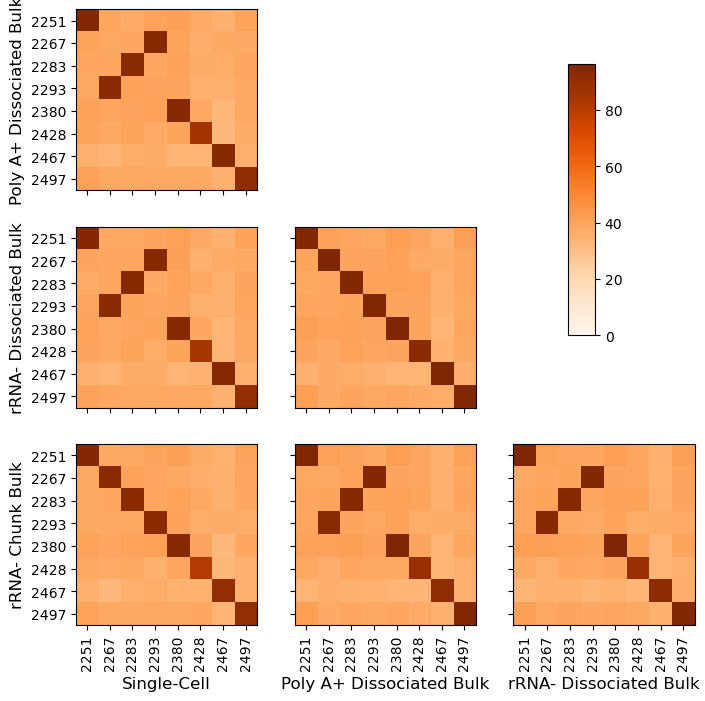

In [6]:
# Figure for supplementary info
super_plot_heatmaps_real_data_multimodal_hgsoc(
    DATA_PATH=DATA_PATH,
    FIGURES_PATH=FIGURES_PATH,
    tool="Conpair",
    rd=0,
    save_fig=True,
)

# Comparison of inferred and expected sample matches

In [ ]:
# # Plot how many matches, non-matches, and NAs there are for each tool across read depths for a given dataset
barplot_matches_nonmatches_na(
    DATA_PATH=DATA_PATH, 
    tools=tools, 
    dataset="high_grade_glioma", 
    read_depths=read_depths, 
    mod1="bulk", 
    mod2="single-cell", 
    save_fig=False, 
    FIGURES_PATH=FIGURES_PATH
    )

In [18]:
merged_df = find_mismatches_real_data(
    DATA_PATH=DATA_PATH, 
    tool="CrosscheckFingerprints", 
    dataset="wilms_tumor", 
    rd1=0, 
    rd2=0,
    mod1="bulk", 
    mod2="single-nucleus"
)
merged_df.sort_values(by="match_status")


Processing tool CrosscheckFingerprints, dataset wilms_tumor, read depth bulk=0, single-nucleus=0...


,single-nucleus sample id,bulk sample id,sample_id_0,sample_id_1,modality_0,modality_1,match_status
87,GSM6025643,<NA>,NaN,NaN,NaN,NaN,left_only
64,GSM6025618,SJWLM071554_D1,NaN,NaN,NaN,NaN,left_only
48,GSM6025608,SJWLM059679_D1,NaN,NaN,NaN,NaN,left_only
6,GSM6025611,SJWLM030545_D1,NaN,NaN,NaN,NaN,left_only
27,GSM6025624,SJWLM051026_D2,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...
42,GSM6025621,SJWLM059660_D1,SJWLM059660_D1,GSM6025621,bulk,single-nucleus,both
13,GSM6025637,SJWLM030897_D2,SJWLM030897_D2,GSM6025637,bulk,single-nucleus,both
41,GSM6025620,SJWLM059659_D1,SJWLM059659_D1,GSM6025620,bulk,single-nucleus,both
10,GSM6025630,SJWLM030739_D2,SJWLM030739_D2,GSM6025630,bulk,single-nucleus,both


In [38]:
merged_df[merged_df["single-nucleus sample id"].str.contains("623", na=False)]

,single-nucleus sample id,bulk sample id,sample_id_0,sample_id_1,modality_0,modality_1,match_status
63,GSM6025623,SJWLM051026_D2,SJWLM051026_D2,GSM6025623,bulk,single-nucleus,both


In [33]:
merged_df[merged_df["match_status"] == "left_only"]

,single-nucleus sample id,bulk sample id,sample_id_0,sample_id_1,modality_0,modality_1,match_status
18,GSM6025611,SJWLM030545_D1,NaN,NaN,NaN,NaN,left_only
64,GSM6025624,SJWLM051026_D2,NaN,NaN,NaN,NaN,left_only
69,GSM6025619,SJWLM056073_D1,NaN,NaN,NaN,NaN,left_only
129,GSM6025608,SJWLM059679_D1,NaN,NaN,NaN,NaN,left_only
168,GSM6025616,SJWLM071552_D1,NaN,NaN,NaN,NaN,left_only
258,GSM6025643,<NA>,NaN,NaN,NaN,NaN,left_only


In [29]:
merged_df["bulk sample id"].nunique()

37

# Combine HYSYS or Crosscheck heatmap & Vireo (linear sum assignment) algorithm

In [153]:
mod1 = "bulk_chunk_ribo"
mod2 = "bulk_diss_polyA"
dataset = "hgsoc-new"

In [ ]:
# _, hysys_matrix = parse_heatmap_matrix_crosscheckfingerprints(
#     DATA_PATH=DATA_PATH, 
#     pseudobulk=False, 
#     dataset=dataset, 
#     ncells="null",
#     rd="bulk_diss_polyA_0_bulk_chunk_ribo_0", 
#     mod1=mod1, 
#     mod2=mod2
# )

In [236]:
_, hysys_matrix = parse_heatmap_matrix_hysys(
    DATA_PATH=DATA_PATH, 
    pseudobulk=False, 
    dataset="high_grade_glioma", 
    ncells="null",
    rd=10, 
    mod1=mod1, 
    mod2=mod2
)

In [237]:
mod1_samples = [idx for idx in hysys_matrix.index if mod1 in idx]
mod2_samples = [col for col in hysys_matrix.columns if mod2 in col]
hysys_matrix = hysys_matrix.loc[mod1_samples, mod2_samples]

In [238]:
# Apply the linear sum assignment algorithm to find the optimal matching
idx0, idx1 = linear_sum_assignment(hysys_matrix.values, True)
matrix_reordered = pd.DataFrame(
    hysys_matrix.iloc[idx0, idx1],
    index=hysys_matrix.index[idx0],
    columns=hysys_matrix.columns[idx1],
)

In [239]:
# If there are more columns than rows (double samples),
# we need to add back the unmatched columns (these were inferred as non-matches)
if len(hysys_matrix.columns) > len(hysys_matrix.index):
    unmatched_cols = [
        col for col in mod2_samples if col not in matrix_reordered.columns
    ]
    for col in unmatched_cols:
        matrix_reordered[col] = 0
# If there are more rows than columns (missing samples),
# we need to add back the unmatched rows (these were inferred as non-matches)
elif len(hysys_matrix.index) > len(hysys_matrix.columns):
    unmatched_rows = [idx for idx in mod1_samples if idx not in matrix_reordered.index]
    for idx in unmatched_rows:
        matrix_reordered.loc[idx] = 0

In [240]:
matrix_reordered.shape

(0, 0)

In [241]:
hysys_matrix.shape

(0, 0)

In [242]:
# Make sure the sample lists are the same length (padded with NaNs if necessary)
padded_lists = itertools.zip_longest(matrix_reordered.index, matrix_reordered.columns, fillvalue=np.nan)
mod1_samples, mod2_samples = zip(*padded_lists)

hysys_vireo_df = pd.DataFrame(
    {
        f"{mod1}": mod1_samples, 
        f"{mod2}": mod2_samples
    }
)

ValueError: not enough values to unpack (expected 2, got 0)

In [243]:
# Split the sample IDs into their components (e.g., "sample1_bulk" -> "sample1", "bulk")
# hysys_vireo_df[["sample_id_0", "modality_0"]] = hysys_vireo_df[f"{mod1}"]#.str.rsplit("_", n=1, expand=True)
# hysys_vireo_df[["sample_id_1", "modality_1"]] = hysys_vireo_df[f"{mod2}"]#.str.rsplit("_", n=1, expand=True)

expected_matches = load_expected_matches_real_data(DATA_PATH, dataset)
print(expected_matches.columns)
print(hysys_vireo_df.columns)

# Merge with expected matches to determine which inferred matches are correct
merged_df = expected_matches.merge(
    hysys_vireo_df,
    left_on=["bulk_chunk_ribo sample id", "bulk_diss_polya sample id"],
    right_on=[mod1, mod2],
    how="outer",
    indicator="match_status"
)

Index(['bulk_chunk_ribo sample id', 'bulk_diss_polya sample id'], dtype='str')
Index(['bulk_chunk_ribo', 'bulk_diss_polyA'], dtype='str')


In [244]:
merged_df

,bulk_chunk_ribo sample id,bulk_diss_polya sample id,bulk_chunk_ribo,bulk_diss_polyA,match_status
0,2018_bulk_chunk_ribo,2018_bulk_diss_polyA,NaN,NaN,left_only
1,2023_bulk_chunk_ribo,2023_bulk_diss_polyA,NaN,NaN,left_only
2,2094_bulk_chunk_ribo,2094_bulk_diss_polyA,NaN,NaN,left_only
3,2126_bulk_chunk_ribo,2126_bulk_diss_polyA,NaN,NaN,left_only
4,2129_bulk_chunk_ribo,2129_bulk_diss_polyA,NaN,NaN,left_only
...,...,...,...,...,...
67,NaN,NaN,HGSOC-2477_bulk_chunk_ribo,HGSOC-2483_bulk_diss_polyA,right_only
68,NaN,NaN,HGSOC-2483_bulk_chunk_ribo,HGSOC-2526_bulk_diss_polyA,right_only
69,NaN,NaN,HGSOC-2507_bulk_chunk_ribo,HGSOC-2514_bulk_diss_polyA,right_only
70,NaN,NaN,HGSOC-2514_bulk_chunk_ribo,NaN,right_only
